In [14]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

In [15]:
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)
len(X), len(y)

(1000, 1000)

In [16]:
import pandas as pd
circles = pd.DataFrame({'X1': X[:, 0], 'X2': X[:,1], 'label': y})
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


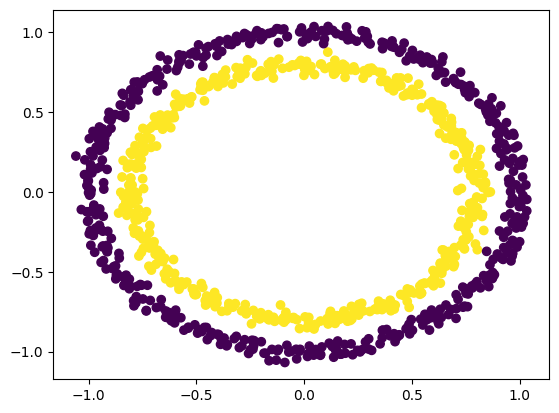

In [17]:
#Plot
plt.scatter(X[:,0], X[:,1], c= y)

In [18]:
#Change data to tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [19]:
#Split to training to test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [20]:
len(X_train), len(X_test)

(800, 200)

In [ ]:
#Set up device
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

Setting up device agnostic code (so our model can run on CPU or GPU if it's available).

Constructing a model by subclassing nn.Module.

Defining a loss function and optimizer.

Creating a training loop (this'll be in the next section).

In [ ]:
#Build model for classification
class CircleModel_0(nn.Module):
    def __init__(self):
        super().__init__()
        #Create two nn.Linear layers
        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)
        
    def forward(self, x):
        return self.layer2(self.layer1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2
    
model_0 = CircleModel_0().to(device)
model_0

CircleModel_0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)